# 10 — Final Test Evaluation, Error Analysis, and Calibration (TensorFlow / Keras)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Only now do we use the test set. The architecture, optimizer and epoch budget were already determined using training/validation evidence. We evaluate accuracy, per-class precision/recall/F1, confusion matrix, examples of failure, confidence and calibration.

**Accuracy alone is not behavioral understanding.** Error analysis asks *which* classes fail and whether the model is uncertain or confidently wrong.


## Code walkthrough — reload the trained artifact and produce test probabilities
Reloading is important: evaluation should test the persisted model artifact, not an accidental in-memory object. The probability matrix has shape `(1000,10)` and becomes the common input to metrics and calibration analysis.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


@tf.keras.utils.register_keras_serializable()
class MNISTMLP(tf.keras.Model):

    def __init__(self, hidden=64, **kwargs):
        super().__init__(**kwargs)
        self.hidden = hidden
        self.fc1 = tf.keras.layers.Dense(
            hidden, activation=None, kernel_initializer="he_normal"
        )
        self.act = tf.keras.layers.ReLU()
        self.fc2 = tf.keras.layers.Dense(
            10, activation=None, kernel_initializer="glorot_uniform"
        )

    def call(self, x, training=False):
        z1 = self.fc1(x)
        a1 = self.act(z1)
        logits = self.fc2(a1)
        return logits


model = MNISTMLP(hidden=64)
_ = model(tf.zeros((1, 784), dtype=tf.float32))
X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
model = tf.keras.models.load_model(ARTIFACT_DIR / "mnist_tensorflow_mlp.keras")
probs = tf.nn.softmax(model(X_test, training=False), axis=1).numpy()

2026-09-07 18:55:13.436938: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Code walkthrough — classification report, confusion matrix and misclassified images
Per-class recall highlights classes the model misses; precision highlights classes receiving false positives. The confusion matrix shows systematic class pairs. Misclassified images keep metrics connected to real inputs.


test accuracy 0.911
              precision    recall  f1-score   support

           0      0.933     0.980     0.956       100
           1      0.933     0.970     0.951       100
           2      0.958     0.920     0.939       100
           3      0.871     0.880     0.876       100
           4      0.908     0.890     0.899       100
           5      0.922     0.830     0.874       100
           6      0.898     0.970     0.933       100
           7      0.947     0.900     0.923       100
           8      0.830     0.930     0.877       100
           9      0.923     0.840     0.880       100

    accuracy                          0.911      1000
   macro avg      0.912     0.911     0.911      1000
weighted avg      0.912     0.911     0.911      1000



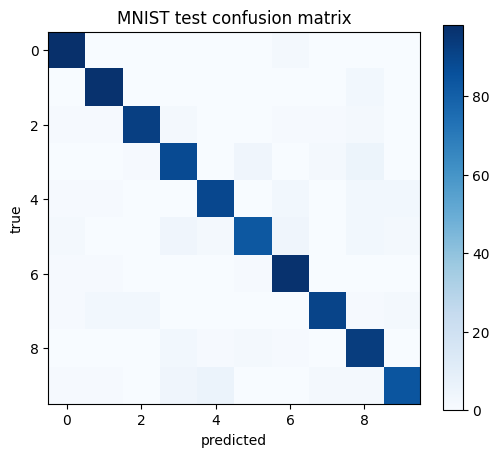

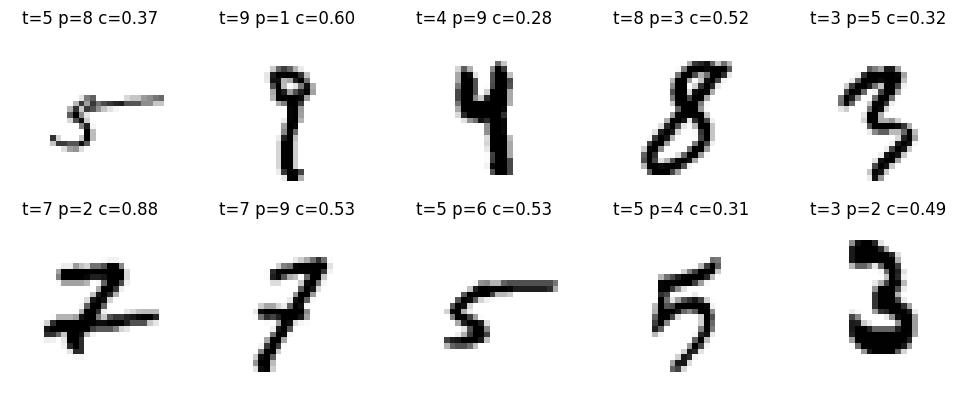

In [2]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pred = probs.argmax(1)
conf = probs.max(1)
print("test accuracy", accuracy_score(y_test, pred))
print(classification_report(y_test, pred, digits=3))
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("MNIST test confusion matrix")
plt.show()
wrong = np.flatnonzero(pred != y_test)[:10]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, i in zip(axes.ravel(), wrong):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"t={y_test[i]} p={pred[i]} c={conf[i]:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Code walkthrough — reliability and Expected Calibration Error (ECE)
Calibration compares confidence with empirical correctness. A model that says “90%” should be correct about 90% of the time in that confidence region. Softmax confidence is not automatically calibrated probability.


ECE 0.06499640291929248


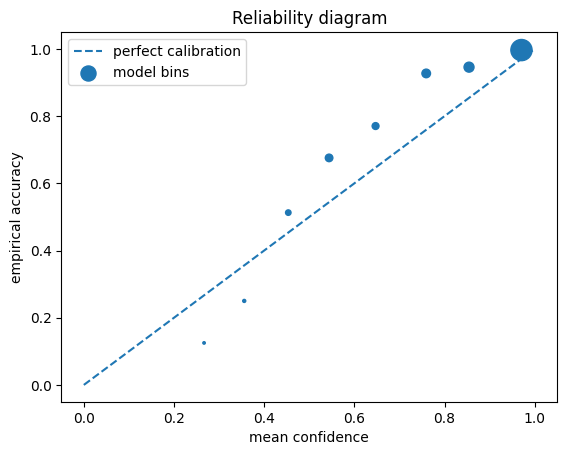

In [3]:
bins = np.linspace(0, 1, 11)
ids = np.digitize(conf, bins) - 1
accs = []
confs = []
counts = []
ece = 0
for b in range(10):
    m = ids == b
    if m.any():
        a = (pred[m] == y_test[m]).mean()
        c = conf[m].mean()
        n = m.sum()
        accs.append(a)
        confs.append(c)
        counts.append(n)
        ece += n / len(y_test) * abs(a - c)
print("ECE", ece)
plt.plot([0, 1], [0, 1], "--", label="perfect calibration")
plt.scatter(confs, accs, s=np.array(counts) * 0.4, label="model bins")
plt.xlabel("mean confidence")
plt.ylabel("empirical accuracy")
plt.legend()
plt.title("Reliability diagram")
plt.show()

## Business implication
If confidence controls automatic approval, escalation or manual review, calibration becomes an operational risk issue. A confidently wrong model can be more harmful than an uncertain one because it bypasses safeguards.


### Interactive Plotly lab — clone + run locally

## Interactive calibration and confidence inspection

> **GitHub vs local behavior.** GitHub keeps the committed static plots, tables, metrics and explanations visible. **Clone this branch, create `environment.yml`, open the notebook in VS Code/Jupyter, select the Conda kernel, and run the cell below for full Plotly interactivity**: hover, zoom, pan, 3D rotation, legend selection, sliders and animation.

This uses the notebook's actual test-set `probs` and `y_test`. Hover the reliability curve to compare mean predicted confidence with empirical accuracy and see how many samples support each bin.

**Production/business interpretation.** The interaction is an inspection instrument, not decoration: change or inspect a technical quantity and connect it to model behavior, operational risk or downstream decision quality.


In [4]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pred = np.asarray(probs).argmax(axis=1); confidence = np.asarray(probs).max(axis=1); correct = (pred == np.asarray(y_test)).astype(float)
edges = np.linspace(0, 1, 11); acc, conf, count = [], [], []
for left, right in zip(edges[:-1], edges[1:]):
    mask = (confidence >= left) & (confidence < right if right < 1 else confidence <= right); count.append(int(mask.sum())); acc.append(float(correct[mask].mean()) if mask.any() else np.nan); conf.append(float(confidence[mask].mean()) if mask.any() else np.nan)
fig = make_subplots(rows=1, cols=2, subplot_titles=("Reliability diagram", "Confidence distribution"))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="perfect calibration", line=dict(dash="dash")), row=1, col=1)
fig.add_trace(go.Scatter(x=conf, y=acc, mode="lines+markers", name="model", text=[f"count={n}" for n in count], hovertemplate="mean confidence=%{x:.3f}<br>accuracy=%{y:.3f}<br>%{text}<extra></extra>"), row=1, col=1)
fig.add_trace(go.Histogram(x=confidence, nbinsx=20, name="confidence"), row=1, col=2)
fig.update_xaxes(title_text="predicted confidence", row=1, col=1); fig.update_yaxes(title_text="empirical accuracy", row=1, col=1); fig.update_xaxes(title_text="confidence", row=1, col=2); fig.update_yaxes(title_text="samples", row=1, col=2); fig.update_layout(title="Interactive calibration and confidence inspection")
if os.getenv("GITHUB_ACTIONS") == "true":
    print("Interactive calibration explorer built. Run locally to hover reliability bins and confidence counts.")
else:
    fig.show(renderer="plotly_mimetype")


Interactive calibration explorer built. Run locally to hover reliability bins and confidence counts.
